<a href="https://colab.research.google.com/github/Dana-fathima/Titanic-Dataset/blob/main/proj_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0 and 1 - in a alphabetical order

In [5]:
import pandas as pd

get the titanic dataset

In [6]:
url='https://raw.githubusercontent.com/rajeevratan84/datascienceforbusiness/refs/heads/master/titanic.csv'

df=pd.read_csv(url)

display the titanic dataset

In [7]:
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


get the column names of titanic dataset

# UNDERSTANDING THE DATASET

In [8]:
df.columns

Index(['pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket', 'fare',
       'cabin', 'embarked', 'survived'],
      dtype='object')

get the information of each column

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   name      1309 non-null   object 
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  survived  1309 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


observation: columns like age,fare,cabin,embarked are having missing values.
All columns are having valid dtype(data type)

# DATA CLEANING

In [10]:
# age  column has to be filled with mean
age_mean=df['age'].mean()
# fare column has to be filled with mean
fare_mean=df['fare'].mean()
# embarked  column has to be filled with mode   or ('unknown)
embarked_mode=df['embarked'].mode()[0]

In [11]:
# fillna() -- used to fill the missing values (None,NaN)

df['age']=df['age'].fillna(age_mean)
df['fare']=df['fare'].fillna(fare_mean)
df['embarked']=df['embarked'].fillna(embarked_mode)

In [12]:
# cabin column which has null values has to be removed from dataset
#-------------------------------------------------------------------
# dropna()
# auto detects the rows and columns which are having missing values and removes them
# axis=0 (remove the rows which are having missing values)
# axis=1 (remove the columns which are having missing values)

df=df.dropna(axis=1)

In [13]:
# convert the fare column dtype
#-----------------------------------------
# astype() - used to convert dtype of columns
#          - we have to pass dict -- {'col':dtype , 'col':dtype ,...........}

df=df.astype({'fare':int})

# DATA TRANSFORMATION

In [14]:
df.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151,S,1


In [15]:
# df['name'].str.split(',',n=1) # list of elements

temp=df['name'].str.split(',',n=1,expand=True) # list has been converted to columns
last_name=temp[0]
t_fname=temp[1]
courtesy_title=t_fname.str.split('.',n=1,expand=True)[0]
first_name=t_fname.str.split('.',n=1,expand=True)[1]
# last_name , courtesy_title , first_name (series)

In [16]:
# creating new columns
df['courtesy_title']=courtesy_title
df['lname']=last_name
df['fname']=first_name

In [17]:
df.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,embarked,survived,courtesy_title,lname,fname
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211,S,1,Miss,Allen,Elisabeth Walton
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151,S,1,Master,Allison,Hudson Trevor


In [18]:
df=df.drop(columns=['name'])
# drop() -- used to remove the rows/records
# index=[indices of row]
# columns=[names of column]

In [19]:
df.head(2)

,pclass,sex,age,sibsp,parch,ticket,fare,embarked,survived,courtesy_title,lname,fname
0,1,female,29.0000,0,0,24160,211,S,1,Miss,Allen,Elisabeth Walton
1,1,male,0.9167,1,2,113781,151,S,1,Master,Allison,Hudson Trevor


In [20]:
df['family_count']=df['sibsp']+df['parch']

In [21]:
df=df.drop(columns=['sibsp','parch'])
df.head(2)

,pclass,sex,age,ticket,fare,embarked,survived,courtesy_title,lname,fname,family_count
0,1,female,29.0000,24160,211,S,1,Miss,Allen,Elisabeth Walton,0
1,1,male,0.9167,113781,151,S,1,Master,Allison,Hudson Trevor,3


In [22]:
# Rename the sex column to gender column
# rename() -- used to change the name of the rows/columns
# for rows --->           index={'old_name' : 'new_name' ,............}
# for columns --->        columns={'old_name' : 'new_name' ,............}
df=df.rename(columns={'sex':'gender'})

In [23]:
df.columns

Index(['pclass', 'gender', 'age', 'ticket', 'fare', 'embarked', 'survived',
       'courtesy_title', 'lname', 'fname', 'family_count'],
      dtype='object')

In [24]:
pd.unique(df['embarked']) # to get unique data in a column

array(['S', 'C', 'Q'], dtype=object)

In [25]:
# replace() --> used to replace the old_values by new_values
#           --> we have to pass dict
df['embarked']=df['embarked'].replace({'S':'Southampton', 'C':'Cherbourg' ,'Q':'Queenstown'})

In [26]:
df.head(2)

,pclass,gender,age,ticket,fare,embarked,survived,courtesy_title,lname,fname,family_count
0,1,female,29.0000,24160,211,Southampton,1,Miss,Allen,Elisabeth Walton,0
1,1,male,0.9167,113781,151,Southampton,1,Master,Allison,Hudson Trevor,3


In [27]:
# creating age_category using age column
df['age_category']=pd.cut(df['age'],bins=[0,2,16,25,49,100],labels=['baby','child','teen','adult','senior'])

In [28]:
df.columns

Index(['pclass', 'gender', 'age', 'ticket', 'fare', 'embarked', 'survived',
       'courtesy_title', 'lname', 'fname', 'family_count', 'age_category'],
      dtype='object')

In [29]:
new_order=['courtesy_title','fname','lname','gender','age','age_category','ticket',
           'pclass','embarked','family_count','fare','survived']

df=df[new_order]

In [30]:
df.head(2)

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.0000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.9167,baby,113781,1,Southampton,3,151,1


In [31]:
pd.unique(df['fare'])
#fare is having 0(which is invalid for traveller)

rowid=df[df['fare']==0].index

rowid

Index([   7,   70,  125,  150,  170,  223,  234,  363,  384,  410,  473,  528,
        581,  896,  898,  963, 1254],
      dtype='int64')

In [32]:
df=df.drop(index=[rowid][0]) #choose the fare in the element (id)
df=df.reset_index(drop=True)


In [33]:
df[df['fare']==0] #verification

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived


In [34]:
df.head(3)

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.0000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.9167,baby,113781,1,Southampton,3,151,1
2,Miss,Helen Loraine,Allison,female,2.0000,baby,113781,1,Southampton,3,151,0


In [35]:
pd.unique(df['family_count'])

array([ 0,  3,  1,  2,  5,  4,  6,  7, 10])

# ANALYSIS

# get the statistical description for all numerical columns

In [36]:
df.describe()

,age,pclass,family_count,fare,survived
count,1292.000000,1292.000000,1292.000000,1292.000000,1292.000000
mean,29.837829,2.301084,0.895511,33.301858,0.385449
std,12.932916,0.836743,1.590759,51.948287,0.486890
min,0.166700,1.000000,0.000000,3.000000,0.000000
25%,22.000000,2.000000,0.000000,7.000000,0.000000
50%,29.881135,3.000000,0.000000,14.000000,0.000000
75%,35.000000,3.000000,1.000000,31.000000,1.000000
max,80.000000,3.000000,10.000000,512.000000,1.000000


# get top 5 records (passengers data)

In [37]:
df.head()

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.0000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.9167,baby,113781,1,Southampton,3,151,1
2,Miss,Helen Loraine,Allison,female,2.0000,baby,113781,1,Southampton,3,151,0
3,Mr,Hudson Joshua Creighton,Allison,male,30.0000,adult,113781,1,Southampton,3,151,0
4,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,female,25.0000,teen,113781,1,Southampton,3,151,0


# get the last 5 records

In [38]:
df.tail()

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
1287,Miss,Hileni,Zabour,female,14.500000,child,2665,3,Cherbourg,1,14,0
1288,Miss,Thamine,Zabour,female,29.881135,adult,2665,3,Cherbourg,1,14,0
1289,Mr,Mapriededer,Zakarian,male,26.500000,adult,2656,3,Cherbourg,0,7,0
1290,Mr,Ortin,Zakarian,male,27.000000,adult,2670,3,Cherbourg,0,7,0
1291,Mr,Leo,Zimmerman,male,29.000000,adult,315082,3,Southampton,0,7,0


# get the total_no_records

In [39]:
#len(df)

df.shape

(1292, 12)

In [40]:
df.shape[0] # 0 -means row  1- means column

1292

In [41]:
df.size

15504

# get the total columns

In [42]:
df.shape[1]

12

# get the first row

In [43]:
df.head(1)

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.0,adult,24160,1,Southampton,0,211,1


In [44]:
df.iloc[0,::] #loc give proirity  otherwise go for iloc

,0
courtesy_title,Miss
fname,Elisabeth Walton
lname,Allen
gender,female
age,29.0
age_category,adult
ticket,24160
pclass,1
embarked,Southampton
family_count,0


In [45]:
df.loc[0,::]#loc give proirity  otherwise go for iloc

,0
courtesy_title,Miss
fname,Elisabeth Walton
lname,Allen
gender,female
age,29.0
age_category,adult
ticket,24160
pclass,1
embarked,Southampton
family_count,0


# get the second row

In [46]:
df.loc[1,::] # if how much record want to be displayed not mentioned then mention all the record
# index=1 indicate it start from the 2nd row record of the data,index start from 0

,1
courtesy_title,Master
fname,Hudson Trevor
lname,Allison
gender,male
age,0.9167
age_category,baby
ticket,113781
pclass,1
embarked,Southampton
family_count,3


# get the fname and age of all passengers

In [47]:
df.loc[::,['fname','age']]#more than one data is passed the make it as list and , seperater

#loc[ , ]before ',' row details afetr ',' column details
#:: to get the all details of the row
# fanem age is asked so it is mention in column space

,fname,age
0,Elisabeth Walton,29.000000
1,Hudson Trevor,0.916700
2,Helen Loraine,2.000000
3,Hudson Joshua Creighton,30.000000
4,Hudson J C (Bessie Waldo Daniels),25.000000
...,...,...
1287,Hileni,14.500000
1288,Thamine,29.881135
1289,Mapriededer,26.500000
1290,Ortin,27.000000


# get the 5th and 6th passenger fname ,age and survived details

In [48]:
df.loc[[5,6],['fname','age','survived']]

,fname,age,survived
5,Harry,48.0,1
6,Kornelia Theodosia,63.0,1


# get the passenger details of pclass 1

In [49]:
cond=df['pclass']==1 #bool value

df.loc[cond,::] #loc[] provides only the ture records from cond_variable


,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.000000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.916700,baby,113781,1,Southampton,3,151,1
2,Miss,Helen Loraine,Allison,female,2.000000,baby,113781,1,Southampton,3,151,0
3,Mr,Hudson Joshua Creighton,Allison,male,30.000000,adult,113781,1,Southampton,3,151,0
4,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,female,25.000000,teen,113781,1,Southampton,3,151,0
...,...,...,...,...,...,...,...,...,...,...,...,...
311,Mr,Fletcher Fellows,Williams-Lambert,male,29.881135,adult,113510,1,Southampton,0,35,0
312,Miss,Helen Alice,Wilson,female,31.000000,adult,16966,1,Cherbourg,0,134,1
313,Mr,Hugh,Woolner,male,29.881135,adult,19947,1,Southampton,0,35,1
314,Mr,George,Wright,male,62.000000,senior,113807,1,Southampton,0,26,0


# get the passenger fname and age of pclass 1

In [50]:
cond1=df['pclass']==1

df.loc[cond1,['fname','age']]

,fname,age
0,Elisabeth Walton,29.000000
1,Hudson Trevor,0.916700
2,Helen Loraine,2.000000
3,Hudson Joshua Creighton,30.000000
4,Hudson J C (Bessie Waldo Daniels),25.000000
...,...,...
311,Fletcher Fellows,29.881135
312,Helen Alice,31.000000
313,Hugh,29.881135
314,George,62.000000


# get the male passenger details of pclass 1

In [51]:
cond=(df['gender']=='male') & (df['pclass']==1) # use ( ) when morethan one condition is given
df.loc[cond,::]

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
1,Master,Hudson Trevor,Allison,male,0.916700,baby,113781,1,Southampton,3,151,1
3,Mr,Hudson Joshua Creighton,Allison,male,30.000000,adult,113781,1,Southampton,3,151,0
5,Mr,Harry,Anderson,male,48.000000,adult,19952,1,Southampton,0,26,1
8,Mr,Ramon,Artagaveytia,male,71.000000,senior,PC 17609,1,Cherbourg,0,49,0
9,Col,John Jacob,Astor,male,47.000000,adult,PC 17757,1,Cherbourg,1,227,0
...,...,...,...,...,...,...,...,...,...,...,...,...
309,Mr,Charles Duane,Williams,male,51.000000,senior,PC 17597,1,Cherbourg,1,61,0
310,Mr,Richard Norris II,Williams,male,21.000000,teen,PC 17597,1,Cherbourg,1,61,1
311,Mr,Fletcher Fellows,Williams-Lambert,male,29.881135,adult,113510,1,Southampton,0,35,0
313,Mr,Hugh,Woolner,male,29.881135,adult,19947,1,Southampton,0,35,1


# get the female passengers fname who were survived in pclass 1

In [52]:
cond=(df['gender']=='female') & (df['pclass']==1) & (df['survived']==1)
df.loc[cond,['fname']] #use list [] to avoid confusion

,fname
0,Elisabeth Walton
6,Kornelia Theodosia
7,Edward Dale (Charlotte Lamson)
10,John Jacob (Madeleine Talmadge Force)
11,Leontine Pauline
...,...
304,George Dennick (Mary Hitchcock)
307,George Dunton (Eleanor Elkins)
308,Constance
312,Helen Alice


# Get the passengers details whose embarked is Southampton, cherbourg

In [53]:
cond=(df['embarked']=='Southampton') | (df['embarked']=='Cherbourg')
df.loc[cond,::]

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.000000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.916700,baby,113781,1,Southampton,3,151,1
2,Miss,Helen Loraine,Allison,female,2.000000,baby,113781,1,Southampton,3,151,0
3,Mr,Hudson Joshua Creighton,Allison,male,30.000000,adult,113781,1,Southampton,3,151,0
4,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,female,25.000000,teen,113781,1,Southampton,3,151,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1287,Miss,Hileni,Zabour,female,14.500000,child,2665,3,Cherbourg,1,14,0
1288,Miss,Thamine,Zabour,female,29.881135,adult,2665,3,Cherbourg,1,14,0
1289,Mr,Mapriededer,Zakarian,male,26.500000,adult,2656,3,Cherbourg,0,7,0
1290,Mr,Ortin,Zakarian,male,27.000000,adult,2670,3,Cherbourg,0,7,0


In [54]:
cond=df['embarked'].isin(['Cherbourg','Southampton']) #to reduce code =,| instead we use 'isin' operator
df.loc[cond,::]

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
0,Miss,Elisabeth Walton,Allen,female,29.000000,adult,24160,1,Southampton,0,211,1
1,Master,Hudson Trevor,Allison,male,0.916700,baby,113781,1,Southampton,3,151,1
2,Miss,Helen Loraine,Allison,female,2.000000,baby,113781,1,Southampton,3,151,0
3,Mr,Hudson Joshua Creighton,Allison,male,30.000000,adult,113781,1,Southampton,3,151,0
4,Mrs,Hudson J C (Bessie Waldo Daniels),Allison,female,25.000000,teen,113781,1,Southampton,3,151,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1287,Miss,Hileni,Zabour,female,14.500000,child,2665,3,Cherbourg,1,14,0
1288,Miss,Thamine,Zabour,female,29.881135,adult,2665,3,Cherbourg,1,14,0
1289,Mr,Mapriededer,Zakarian,male,26.500000,adult,2656,3,Cherbourg,0,7,0
1290,Mr,Ortin,Zakarian,male,27.000000,adult,2670,3,Cherbourg,0,7,0


# Get the no_of passengers
# Get the no_of male passengers

In [55]:
df.shape[0]

#Get the no_of passengers


1292

In [56]:
len(df)#Get the no_of passengers


1292

In [57]:
df['pclass'].count()#Get the no_of passengers


np.int64(1292)

In [58]:
#Get the no_of male passenger
cond=df['gender']=='male'
df.loc[cond,['gender']].count()

,0
gender,826


# Get the highest fare
# Get the lowest fare among female passengers

In [59]:
#Get the highest fare
df['fare'].max()

512

In [60]:
#Get the highest fare
df.loc[::,['fare']].max()

,0
fare,512


In [61]:
#get the lowest fare among female passengers


cond=df['gender']=='female'
df.loc[cond,['fare']].min()

,0
fare,6



# Get the no_of_survivals
# Get the survival rate

In [62]:
#Get the no_of_survivals
cond=df['survived']==1
df.loc[cond,['survived']].count()

,0
survived,498


In [63]:
#Get the no_of_survivals
df.loc[::,['survived']].sum()

,0
survived,498


get the no.of missing values in age column(assuming missing values exist)

In [64]:
#isnull search for null values  present in the column
#df['age'].isnull()
#false,falese ,false..... which means 0 o ading 0 will get 0

df['age'].isnull().sum()



np.int64(0)

In [65]:
#Get the survival rate

cond=df['survived']==1
df.loc[cond,['survived']].mean()



,0
survived,1.0


# Get the aggregates for fare column

# Get the no_of_passengers in each gender

In [66]:
#Get the aggregates for fare column

#aggregates-count,min,max,mean,sum

df.agg({'fare':['count','min','max','mean','sum'],})


,fare
count,1292.000000
min,3.000000
max,512.000000
mean,33.301858
sum,43026.000000


In [67]:
#Get the no_of_passengers in each gender

gp_obj=df.groupby(['gender'])
gp_obj['gender'].count()

,gender
gender,
female,466
male,826


# Get the total fare in each pclass

In [68]:
gp_obj=df.groupby(['pclass'])
gp_obj['fare'].sum()

,fare
pclass,
1,28129
2,5806
3,9091


# Get the pclass wise survival rate and count

OBSERVATION: in pclass 3,the no.of passenger is high compare to other pclass but the survial rate is lessthan from others . in pclass 1 the facilities is more and it help people to survive and in pclass3 the facillities is less compare to other so the survial rate is less.

In [69]:
gp_obj=df.groupby(['pclass'])
gp_obj.agg({'survived':['mean','count']})



survived      
            mean count
pclass                
1       0.629747   316
2       0.439114   271
3       0.255319   705

# Get the pclass,gender wise survival rate

OBSERVATION: Comparing all the pclass the survial rate of female passenger is morethan male passenger, most of the female passenger is survived from all the pclass.

In [70]:
gp_obj=df.groupby(['pclass','gender'])
gp_obj.agg('survived').mean()

pclass  gender
1       female    0.965278
        male      0.348837
2       female    0.886792
        male      0.151515
3       female    0.490741
        male      0.151329
Name: survived, dtype: float64

# Get the no.of.psgn in each pclass

OBSERVATION:the no.of passenger in pclass 3 is twice as pclass1 and almost thrice as pclass 2

In [71]:
gp_obj=df.groupby(['pclass'])
gp_obj['pclass'].count()

,pclass
pclass,
1,316
2,271
3,705


# Find the pclass in which highest no_of_passengers are there

In [72]:
gp_obj=df.groupby(['pclass'])
gp_obj['pclass'].count().idxmax()

np.int64(3)

# Find the pclass in which lowest no_of_passengers are there

In [73]:
gp_obj=df.groupby(['pclass'])
gp_obj['pclass'].count().idxmin()

np.int64(2)

# Find the no.of.familes travelling

In [74]:
gp_obj=df.groupby(['ticket'])
gp_obj['ticket'].count()

,ticket
ticket,
110152,3
110413,3
110465,2
110469,1
110489,1
...,...
W./C. 6608,5
W./C. 6609,1
W.E.P. 5734,2


In [75]:
df.groupby('ticket')['ticket'].count()

,ticket
ticket,
110152,3
110413,3
110465,2
110469,1
110489,1
...,...
W./C. 6608,5
W./C. 6609,1
W.E.P. 5734,2


# Find the no.of.familes travelling  and  survival rate


In [76]:
df.groupby('ticket').agg({'survived':['count','mean']})

survived          
               count      mean
ticket                        
110152             3  1.000000
110413             3  0.666667
110465             2  0.000000
110469             1  0.000000
110489             1  0.000000
...              ...       ...
W./C. 6608         5  0.000000
W./C. 6609         1  0.000000
W.E.P. 5734        2  0.500000
W/C 14208          1  0.000000
WE/P 5735          2  0.500000

[918 rows x 2 columns]

OBSERVATION:
if family count is zero doesnot mean that they are travelling alone ,if ticket number is same doesnot mean that they are family




In [77]:
df.loc[(df['ticket']=='110152'),::] # to verification
#if family count is zero doesnot mean that they are travelling alone ,if ticket number is same doesnot mean that they are family

,courtesy_title,fname,lname,gender,age,age_category,ticket,pclass,embarked,family_count,fare,survived
66,Miss,Gladys,Cherry,female,30.0,adult,110152,1,Southampton,0,86,1
190,Miss,Roberta,Maioni,female,16.0,child,110152,1,Southampton,0,86,1
238,the Countess,of (Lucy Noel Martha Dyer-Edwards),Rothes,female,33.0,adult,110152,1,Southampton,0,86,1


# find the correlation between the numerical columns

neagtive is inversly preportion

1.age with plcass
2.age with survived
3.plcass with fare- when pclass 1 have high fare , and pclass 2 have lesser fare, pclass 3 have lowest fare ,which means when pclass no increases the fare decreases ,which is invwesly prop (-0.570109).
4. etc......


In [78]:
df.corr(numeric_only=True)

,age,pclass,family_count,fare,survived
age,1.000000,-0.366397,-0.196047,0.174783,-0.049676
pclass,-0.366397,1.000000,0.046349,-0.570109,-0.321205
family_count,-0.196047,0.046349,1.000000,0.222935,0.023038
fare,0.174783,-0.570109,0.222935,1.000000,0.241527
survived,-0.049676,-0.321205,0.023038,0.241527,1.000000


# What is correlation b/w fare and pclass

# what is the correlate b/w fare and survival

# What is correlation b/w age and survival

In [79]:
#What is correlation b/w fare and pclass

df.loc[::,['fare','pclass']].corr()

,fare,pclass
fare,1.000000,-0.570109
pclass,-0.570109,1.000000


when u are giving combination of numeric and alphabet columns the give numeric_onl=True

otherwise we donot want to use numeric_only=True

In [80]:
#what is the correlate b/w fare and survival
df.loc[::,['fare','survived']].corr()

,fare,survived
fare,1.000000,0.241527
survived,0.241527,1.000000


In [81]:
#What is correlation b/w age and survival
df.loc[::,['age','survived']].corr()

,age,survived
age,1.000000,-0.049676
survived,-0.049676,1.000000


# Get the pclass wise male and female count and survival rate

***`find the correlation btw gender and survival`***

In [82]:

# df.groupby('pclass').agg([{'gender':['count']},{'survived':['mean']}])

temp=df['gender'].map({'male':0,'female':1})
#print(temp)
df.loc[::,'survived'].corr(temp)

np.float64(0.5278258125759904)

***find the correlation btw age category and survival***

In [83]:
pd.unique('age_category')

<ipython-input-83-48b771fa0249>:1: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.unique('age_category')


array(['age_category'], dtype=object)

In [84]:
pd.unique(df['age_category'])

['adult', 'baby', 'teen', 'senior', 'child']
Categories (5, object): ['baby' < 'child' < 'teen' < 'adult' < 'senior']

In [85]:
temp=df['age_category'].map({'adult':0,'baby':1,'child':2,'senior':3,'teen':4})
df.loc[::,'survived'].corr(temp)

np.float64(0.0186775604711981)

# Get the age_seg wise no.of.psgns and survival rate

# Get the age_seg which has high_survivale rate

# Get the gender and age_seg which has high survival rate

# Get the pclass,age_seg,gender in which survival rate is high

# Get the solo travelers full name

# solo travelers survival rate v/s psngs  with family survival rate

# Find the gender and pclass wise survival rate of solo travelers

# PLOT.................................


In [86]:
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Plot the total count of male and female passengers.


[Text(0, 0, '466'), Text(0, 0, '826')]

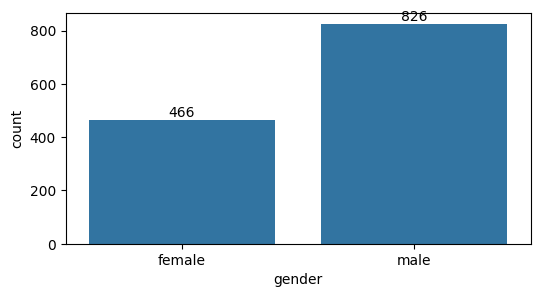

In [87]:
plt.figure(figsize=(6,3))
a=sns.countplot(data=df,x='gender')
a.bar_label(a.containers[0])



# 2. Plot the total count of male and female passengers in each passenger class.


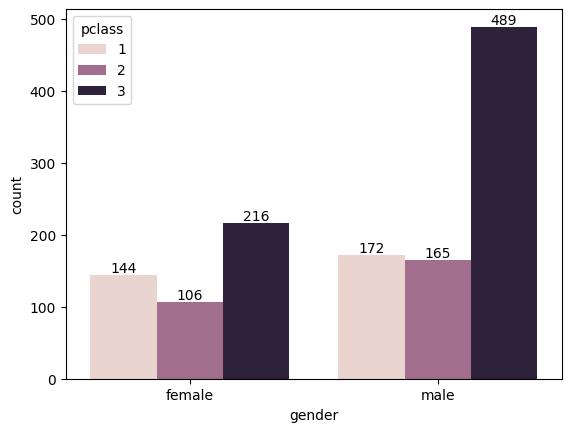

In [88]:
a=sns.countplot(data=df,x='gender',hue='pclass')

for c in a.containers:
    # a.bar_label(a.containers[0])
    a.bar_label(c)


# 3. Plot the count of survived and non-survived passengers.



([<matplotlib.axis.XTick at 0x79258d009050>,
 [Text(0, 0, 'not survived'), Text(1, 0, 'survived')])

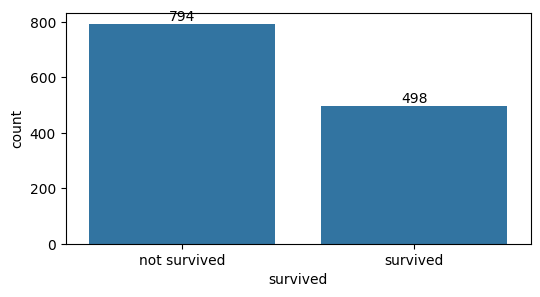

In [89]:
plt.figure(figsize=(6,3))
a=sns.countplot(data=df,x='survived')
a.bar_label(a.containers[0])
plt.xticks([0,1],labels=['not survived','survived'])

# 4. Plot the gender-wise count of survived and non-survived passengers.


([<matplotlib.axis.XTick at 0x79258d073690>,
 [Text(0, 0, 'not survived'), Text(1, 0, 'survived')])

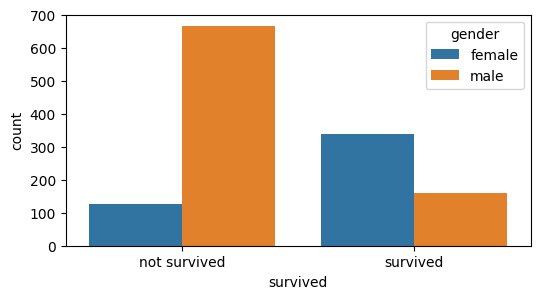

In [90]:
plt.figure(figsize=(6,3))
a=sns.countplot(data=df,x='survived',hue='gender')

plt.xticks([0,1],labels=['not survived','survived'])


# 5. Plot the count of passengers in each age category.



[Text(0, 0, '34'),
 Text(0, 0, '100'),
 Text(0, 0, '307'),
 Text(0, 0, '741'),
 Text(0, 0, '110')]

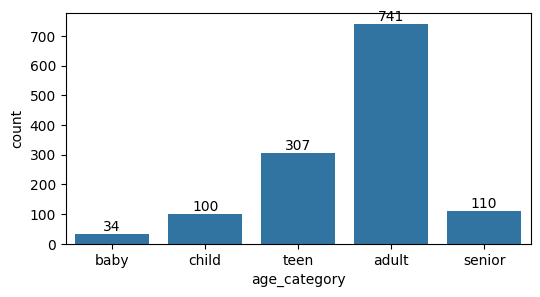

In [91]:
plt.figure(figsize=(6,3))
a=sns.countplot(data=df,x='age_category')
a.bar_label(a.containers[0])

OBSERVATION:

# 6. Plot the count of survived and non-survived passengers in each age category.


([<matplotlib.axis.XTick at 0x79258cf716d0>,
 [Text(0, 0, 'not survived'), Text(1, 0, 'survived')])

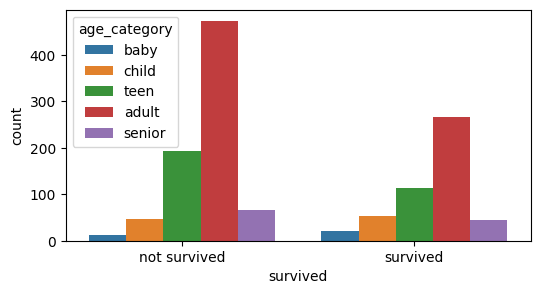

In [92]:
plt.figure(figsize=(6,3))
a=sns.countplot(data=df,x='survived',hue='age_category')
plt.xticks([0,1],labels=['not survived','survived'])

OBSERVATION: adults are more in which pclass
adults are more in which gender


# 7. Plot the number of passengers who boarded at each port.



In [93]:
plt.figure(figsize=(6,3))


<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

# 8. Plot the total fare collected for each passenger class.



[Text(0, 0, '28129'), Text(0, 0, '5806'), Text(0, 0, '9091')]

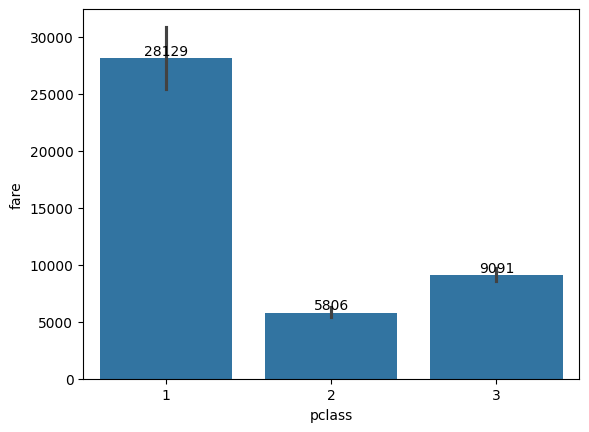

In [94]:
a=sns.barplot(data=df,x='pclass',y='fare',estimator='sum')
a.bar_label(a.containers[0])

# 9. Plot the total fare collected for each gender.



[Text(0, 0, '21328'), Text(0, 0, '21698')]

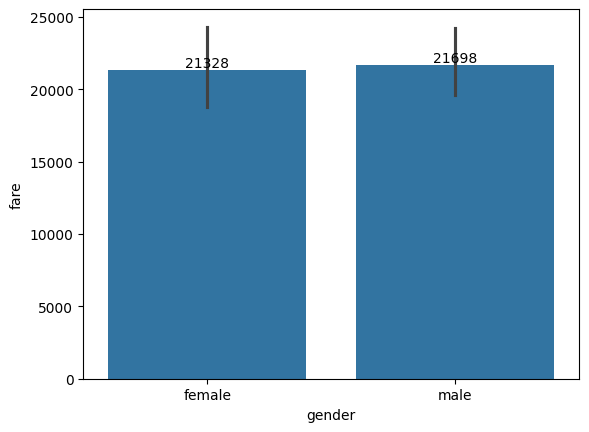

In [95]:
a=sns.barplot(data=df,x='gender',y='fare',estimator='sum')
a.bar_label(a.containers[0])

# 10. Plot the average fare for each passenger class.



[Text(0, 0, '89.0158'), Text(0, 0, '21.4244'), Text(0, 0, '12.895')]

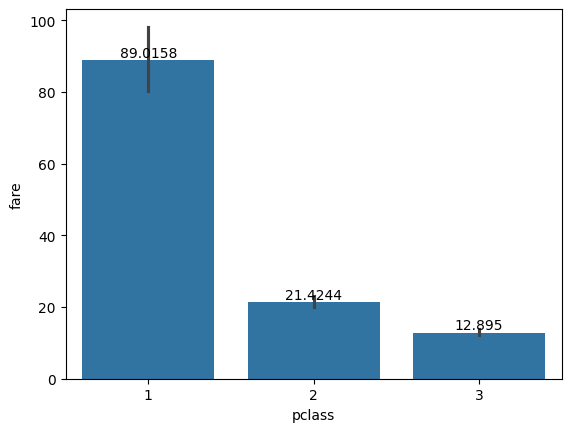

In [96]:
a=sns.barplot(data=df,x='pclass',y='fare',estimator='mean')
a.bar_label(a.containers[0])

# 11. Plot the percentage of passengers in each age category.


In [97]:
count=df['age_category'].value_counts()
count


,count
age_category,
adult,741
teen,307
senior,110
child,100
baby,34


([<matplotlib.patches.Wedge at 0x79258cccfe50>,
 [Text(-0.25184566238798006, 1.0707818462863292, 'adult'),
  Text(-0.3898727673245138, -1.0285908930662013, 'teen'),
  Text(0.6671594258583761, -0.8745846445532429, 'senior'),
  Text(1.0094877998319454, -0.43696038949824545, 'child'),
  Text(1.0962429961658902, -0.09083663004114723, 'baby')],
 [Text(-0.13737036130253458, 0.5840628252470885, '57.35%'),
  Text(-0.21265787308609843, -0.5610495780361098, '23.76%'),
  Text(0.36390514137729596, -0.47704616975631425, '8.51%'),
  Text(0.5506297089992429, -0.23834203063540657, '7.74%'),
  Text(0.5979507251813946, -0.049547252749716664, '2.63%')])

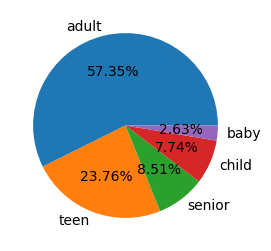

In [98]:
plt.figure(figsize=(6,3))
plt.pie(data=df,x=count.values,labels=count.index,autopct='%2.2f%%')

([<matplotlib.patches.Wedge at 0x79258cd7e5d0>,
 [Text(-0.25184566238798006, 1.0707818462863292, ''),
  Text(-0.3898727673245138, -1.0285908930662013, ''),
  Text(0.6671594258583761, -0.8745846445532429, ''),
  Text(1.0094877998319454, -0.43696038949824545, ''),
  Text(1.0962429961658902, -0.09083663004114723, '')])

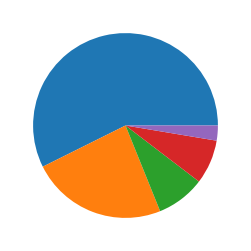

In [99]:

plt.figure(figsize=(6,3))
plt.pie(data=df,x=count)


# 12. Plot the relationship between fare and passenger class.


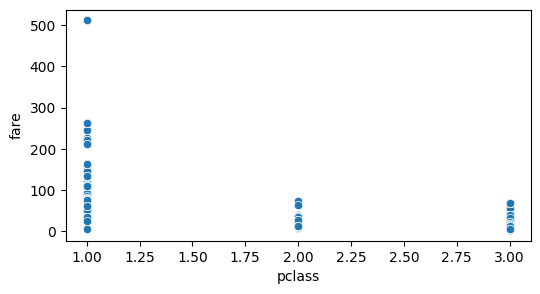

In [100]:
plt.figure(figsize=(6,3))
a=sns.scatterplot(data=df,x='pclass',y='fare')


OBSERVATION:fare is decreased


# 13. Plot the distribution of fares.


<Axes: xlabel='fare', ylabel='Density'>

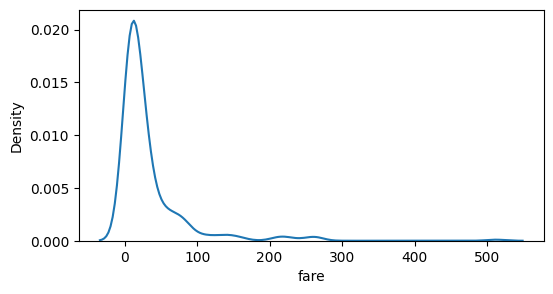

In [101]:
import numpy as np

#when the distribution is asked go for kdeplot
plt.figure(figsize=(6,3))
sns.kdeplot(data=df,x='fare')

#plt.xticks(np.arange(2,5,5))

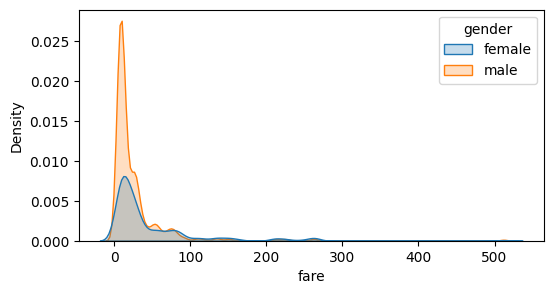

In [102]:
plt.figure(figsize=(6,3))
a=sns.kdeplot(data=df,x='fare',hue='gender',fill=True,bw_adjust=0.45)

OBSERVATION: more passenger brought the ticket which have less fare i.e, more ticket is purchased btw 0-100


# 14. Plot the distribution of ages.


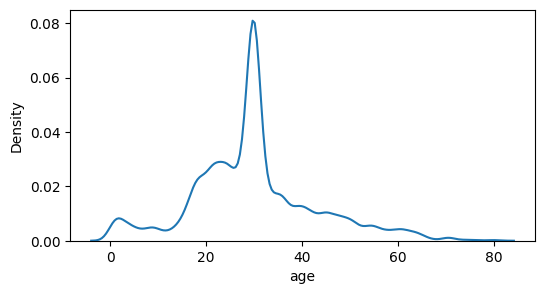

In [103]:
plt.figure(figsize=(6,3))
a=sns.kdeplot(data=df,x='age',bw_adjust=0.45)

OBSERVATION: there are more no.of passengers whose age is btw 25 to 35.


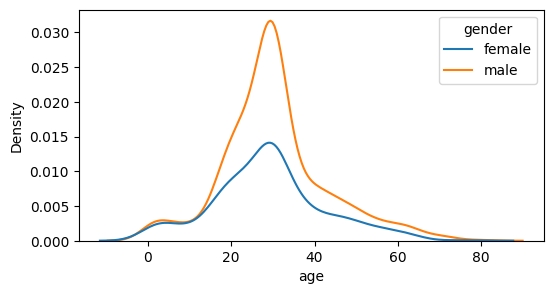

In [106]:
plt.figure(figsize=(6,3))
a=sns.kdeplot(data=df,x='age',hue='gender')


OBSERVATION: there are more male passenger who's age falls under 25-35 .


# 15. Plot the survival rate in each passenger class.


[Text(0, -30, '62.97%'), Text(0, -30, '43.91%'), Text(0, -30, '25.53%')]

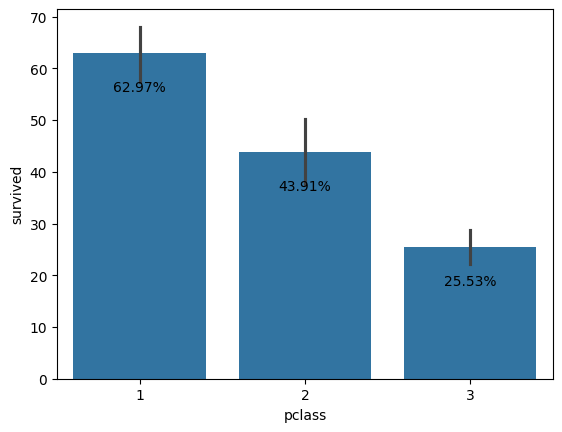

In [107]:
a=sns.barplot(data=df,x='pclass',y='survived',estimator=lambda z:(sum(z)/len(z))*100) #z is survived (y-axix)
a.bar_label(a.containers[0],fmt='%.2f%%',padding=-30)

#fmt='%.2f'-- to round the decimal to 2 points
#estimator=lambda z:(sum(z)/len(z))*100     to convert into percentage
#fmt='%.2f%% to get the sign of percentage

#padding --is used to move the label number
#if padding=+ve value it will move upward
#padding =-ve value it will move downwards



# 16. Plot the survival rate in each age category.


OBSERVATION: in age category, baby category have more survival rate with 61.76%,secoundly survival rate goes for child with 53% .

[Text(0, -90, '61.76%'),
 Text(0, -90, '53.00%'),
 Text(0, -90, '36.81%'),
 Text(0, -90, '36.03%'),
 Text(0, -90, '40.00%')]

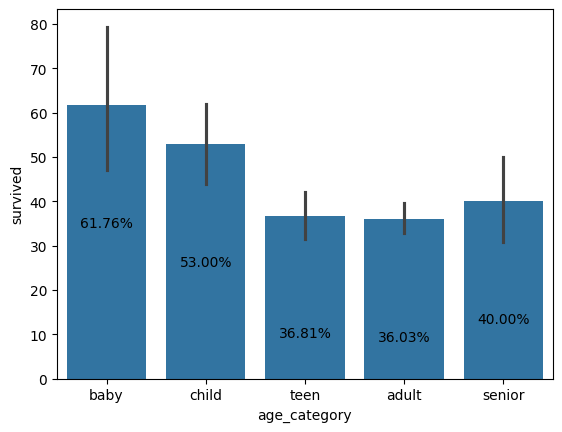

In [108]:
a=sns.barplot(data=df,x='age_category',y='survived',estimator=lambda z:(sum(z)/len(z))*100) #z is survived (y-axix)
a.bar_label(a.containers[0],fmt='%.2f%%',padding=-90)

# WHY FEMALE PASSENGER HAVING HIGH SURVIVAL CHANCES THAN MALE IN THE ALL PCLASS

OBSERVATION: in each class the survival rate of female is more than male.

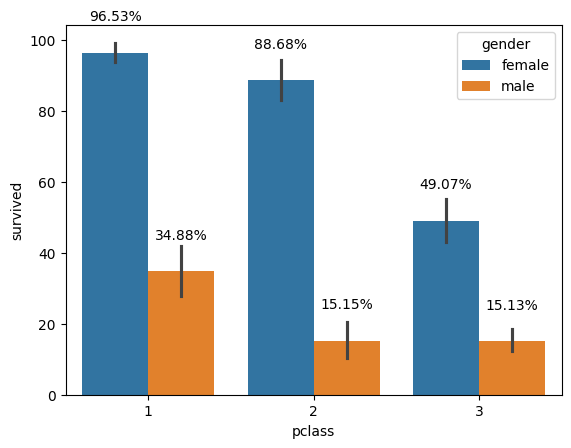

In [109]:
a=sns.barplot(data=df,x='pclass',y='survived',estimator=lambda z:(sum(z)/len(z))*100,hue='gender') #z is survived (y-axix)


for c in a.containers:
  a.bar_label(c,fmt='%.2f%%',padding=21)




# 17. Plot the variation in fare and age.


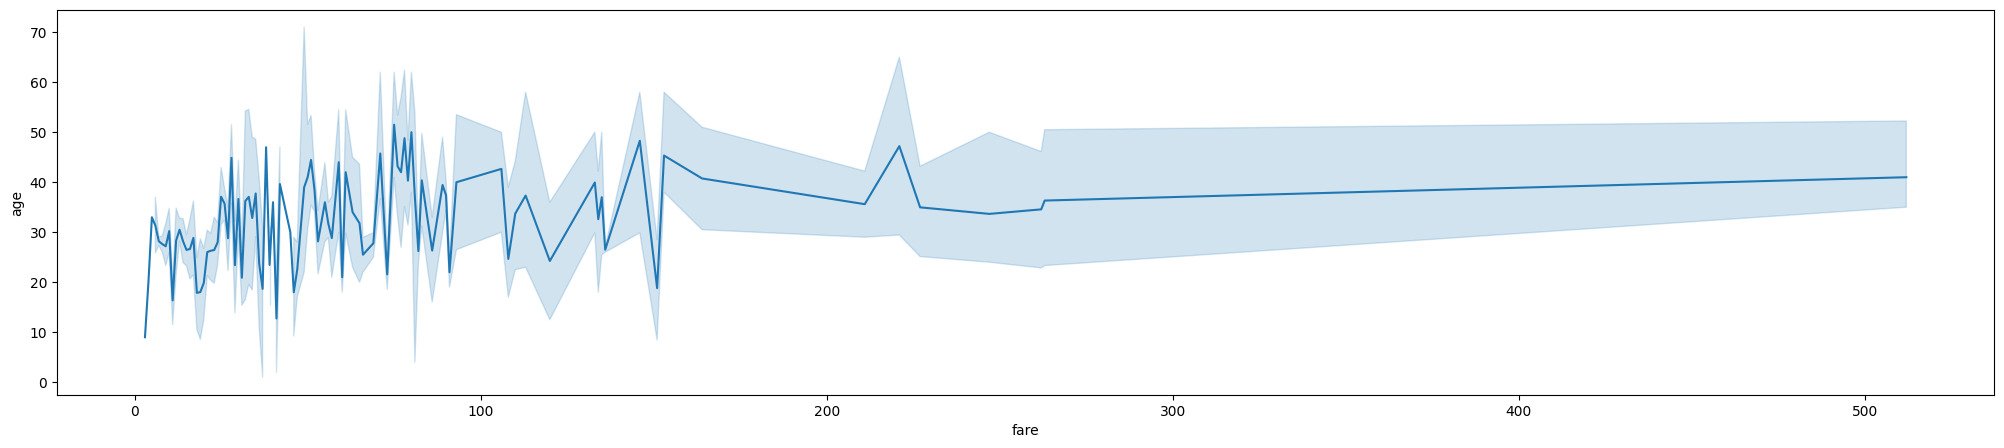

In [110]:
plt.figure(figsize=(25,5))
a=sns.lineplot(data=df,x='fare',y='age')


# 18.  Did fare affect survival.


OBSERVATION: when fare is more the the survival rate is higher .

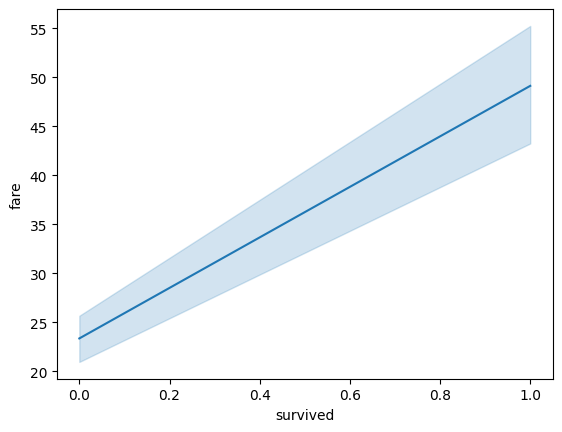

In [111]:
a=sns.lineplot(data=df,x='survived',y='fare')

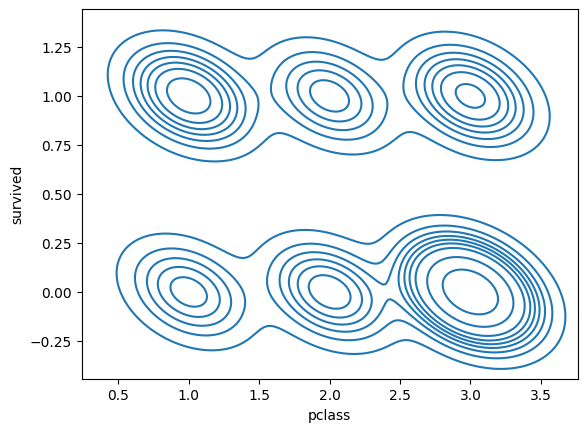

In [112]:
df.loc[::,['fare','survived']].corr()
a=sns.kdeplot(data=df,x='pclass',y='survived')


# 19.  Is there any role of age in survival.



[Text(0, 22, '21'),
 Text(0, 22, '53'),
 Text(0, 22, '113'),
 Text(0, 22, '267'),
 Text(0, 22, '44')]

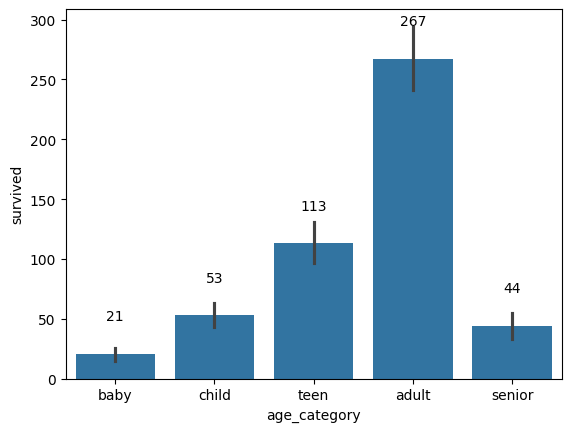

In [113]:
a=sns.barplot(data=df,x='age_category',y='survived',estimator='sum')
a.bar_label(a.containers[0],padding=22)

In [114]:
gp=df.groupby(['age_category'])
c=gp['survived'].count()
c

<ipython-input-114-bef12c613ed5>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gp=df.groupby(['age_category'])


,survived
age_category,
baby,34
child,100
teen,307
adult,741
senior,110


([<matplotlib.patches.Wedge at 0x792589d1e510>,
 [Text(1.0962429417065307, 0.09083728727021889, 'baby'),
  Text(1.0094875932069045, 0.43696086685346486, 'child'),
  Text(0.18896392380300453, 1.0836478373996659, 'teen'),
  Text(-0.76254057019302, -0.7928000244763519, 'adult'),
  Text(1.0608861589416823, -0.2907241953569809, 'senior')],
 [Text(0.5979506954762893, 0.04954761123830121, '2.63%'),
  Text(0.5506295962946751, 0.2383422910109808, '7.74%'),
  Text(0.10307123116527518, 0.5910806385816358, '23.76%'),
  Text(-0.4159312201052836, -0.43243637698710097, '57.35%'),
  Text(0.5786651776045539, -0.15857683383108048, '8.51%')])

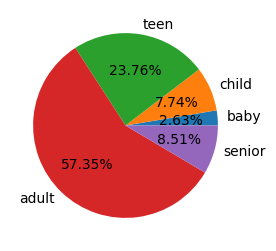

In [115]:
plt.figure(figsize=(6,3))
plt.pie(data=df,x=c.values,labels=c.index,autopct='%2.2f%%')

# 20.  Why did females have more survival chances than males? Which factor influenced this.

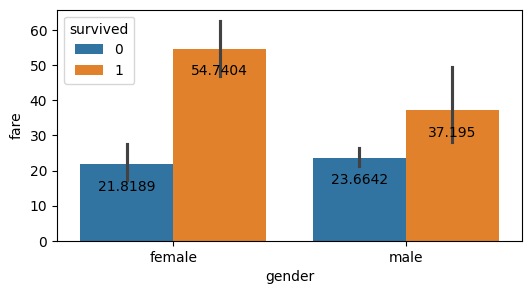

In [116]:
plt.figure(figsize=(6,3))
a=sns.barplot(data=df,x='gender',y='fare',hue='survived',estimator='mean')

for c in a.containers:
  a.bar_label(c,padding=-21)


